UCI 데이터셋을 활용한 포르투갈 레드 와인의 품질관리성분 및 관리기준 예측 분석 연구: CART 알고리즘 기반의 의사결정나무(Decision tree) 기법을 중심으로 (kci.go.kr)

https://www.kci.go.kr/kciportal/ci/sereArticleSearch/ciSereArtiView.kci?sereArticleSearchBean.artiId=ART002747450

이의 결과로 알콜농도(A), 황산염(S), 휘발산(VA), 산도(pH)의 4가지 성분 변수가 품질 예측 변수로 도출되었다. 도출된 4가지 품질 예측변수는 인공신경망 MLP알고리즘, AIC값, regsubsets 함수 알고리즘을 통해 교차 검증되었다. 품질 예측 변수의 관리 기준은 CART 알고리즘의 분석 결과인 분기 기준 값을 적용하였다. 이의 결과로 가장 높은 와인 품질(와인 품질 6.8)의성분 기준은 알콜(11<=, <12), 황산염(0.65<=), 휘발산도(<0.4), pH(<3.3)으로 예측되었다. 일정 수준의 고품질의 와인(와인 품질 6.7)의 성분 기준은 알콜(12<), 황산염(0.65<)으로 예측되었다. 이러한 예측된 성분기준은 와인 생산의 품질 관리에 적용이 가능한 것으로 보이며, 적절한 성분 예측을 통한 품질 관리는 최종제품을 분류하는 기준의 하나로서 제시가 가능할 것으로 보인다.

26646202.pdf (stanford.edu)
Predicting Style and Quality of Vinho Verde fromits Physical Properties


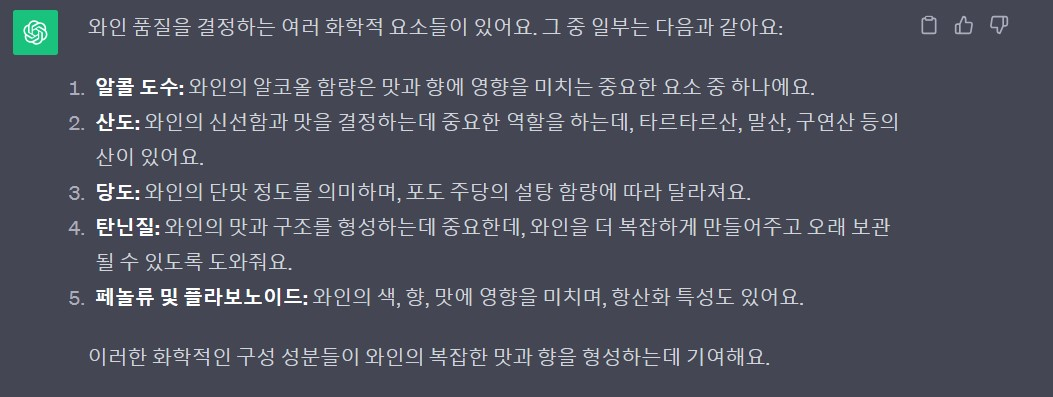

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 데이터 로드
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_2 = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
red_wine_data = pd.read_csv(url, sep=";")
white_wine_data = pd.read_csv(url_2, sep=";")

In [ ]:
# 데이터 확인
red_wine_data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [ ]:
# 데이터에 로그 변환 적용
X = np.log(red_wine_data)
# y값에도 적용 해야 하는가???
X

/usr/local/lib/python3.10/dist-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,2.001480,-0.356675,-inf,0.641854,-2.577022,2.397895,3.526361,-0.002202,1.255616,-0.579818,2.240710,1.609438
1,2.054124,-0.127833,-inf,0.955511,-2.322788,3.218876,4.204693,-0.003205,1.163151,-0.385662,2.282382,1.609438
2,2.054124,-0.274437,-3.218876,0.832909,-2.385967,2.708050,3.988984,-0.003005,1.181727,-0.430783,2.282382,1.609438
3,2.415914,-1.272966,-0.579818,0.641854,-2.590267,2.833213,4.094345,-0.002002,1.150572,-0.544727,2.282382,1.791759
4,2.001480,-0.356675,-inf,0.641854,-2.577022,2.397895,3.526361,-0.002202,1.255616,-0.579818,2.240710,1.609438
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,1.824549,-0.510826,-2.525729,0.693147,-2.407946,3.465736,3.784190,-0.005113,1.238374,-0.544727,2.351375,1.609438
1595,1.774952,-0.597837,-2.302585,0.788457,-2.780621,3.663562,3.931826,-0.004892,1.258461,-0.274437,2.415914,1.791759
1596,1.840550,-0.673345,-2.040221,0.832909,-2.577022,3.367296,3.688879,-0.004269,1.229641,-0.287682,2.397895,1.791759
1597,1.774952,-0.438505,-2.120264,0.693147,-2.590267,3.465736,3.784190,-0.004540,1.272566,-0.342490,2.322388,1.609438


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# 변수 간의 관계 파악
plt.figure(figsize=(12, 8))
sns.heatmap(red_wine_data.corr(), annot=True, fmt=".2f")

plt.show()

NameError: ignored

<Figure size 1200x800 with 0 Axes>

상관계수들은 위와 같이 나온다. \
1.alcohol과 sulphates의 값이 quality의 양의 상관관계를 나타내고
2.각 설명변수들간의 상관관계또한 명확하게 나타난다.

In [ ]:
import seaborn as sns

# Pairwise scatter plot 그리기
sns.set(style="ticks")
sns.pairplot(X, diag_kind='kde', markers='o')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 데이터 분할
y = X['quality']
X = X.drop('quality', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 선형 회귀 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

ValueError: ignored

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 모델 학습
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 예측 및 성능 평가
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MSE:', mse)
print('R2 Score:', r2)

# 특성 중요도 확인
importance = pd.DataFrame(model.feature_importances_, X.columns, columns=['Importance'])
print(importance)

ValueError: ignored